# Movement Branch — HAR model for ESP32

Trains the **movement** leg of the multimodal threat detector: a quantized 1D CNN
that runs in ~20-60 KB of flash and a ~30-60 KB tensor arena on an ESP32.

---

## 1. Setup

In [ ]:
# ON COLAB: install nothing. TensorFlow, NumPy, scikit-learn and matplotlib are
# all preinstalled and mutually compatible. Running `pip install tensorflow==...`
# here downgrades NumPy underneath a live kernel and breaks it with
# "numpy.dtype size changed, may indicate binary incompatibility" -- pip cannot
# hot-swap a C extension. If you already did that: Runtime > Restart session.
#
# Only on a bare non-Colab environment:
#     pip install tensorflow scikit-learn matplotlib

import os, glob, json, textwrap, shutil
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

WIN     = 128    # timesteps = 2.56 s @ 50 Hz. Matches UCI HAR's native windowing.
STRIDE  = 64     # 50% overlap (used for MotionSense, which is continuous)
FS      = 50     # Hz
CH      = 6      # body_acc xyz (g) + body_gyro xyz (rad/s)

CLASSES = ["walk", "upstairs", "downstairs", "sit", "stand", "lay", "jog"]
CLS = {c: i for i, c in enumerate(CLASSES)}
N_CLS = len(CLASSES)

USE_MOTIONSENSE = True   # set False for a quicker UCI-only first pass

# UCI_ROOT and MS_ROOT are set by the download cell below.
print(f"window {WIN} steps = {WIN/FS:.2f} s @ {FS} Hz, {CH} channels, {N_CLS} classes")
print(f"numpy {np.__version__}")

window 128 steps = 2.56 s @ 50 Hz, 6 channels, 7 classes
numpy 2.0.2


### Download the datasets

Run this once per Colab session. Both sources are direct HTTP

In [ ]:
import os, glob, zipfile, shutil

# ---------------------------------------------------------------------------
# Sources. MotionSense comes from the author's own GitHub repo, so no Kaggle
# account or API token is needed. UCI is listed twice: their host has
# intermittent TLS/rate-limit trouble, so the long-stable Coursera CloudFront
# mirror is the fallback. Both contain identical data.
# ---------------------------------------------------------------------------
UCI_URLS = [
    "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip",
    "https://d396qusza40orc.cloudfront.net/getdata/projectfiles/UCI%20HAR%20Dataset.zip",
]
MS_URL = "https://github.com/mmalekzadeh/motion-sense/raw/master/data/A_DeviceMotion_data.zip"


def fetch(urls, dest, min_mb=5):
    """Try each mirror in turn. Returns the URL that worked."""
    if isinstance(urls, str):
        urls = [urls]
    for u in urls:
        print(f"  -> {u}")
        rc = os.system(f'curl -L --fail --retry 3 --retry-delay 2 -# -o "{dest}" "{u}"')
        if rc == 0 and os.path.exists(dest) and os.path.getsize(dest) > min_mb * 1e6:
            print(f"     ok, {os.path.getsize(dest)/1e6:.1f} MB")
            return u
        print("     failed, trying next mirror")
    raise RuntimeError(
        f"all mirrors failed for {dest}. Download it by hand, upload it to this "
        f"session as '{dest}', and re-run this cell -- it will reuse the file.")


def ensure_zip(urls, dest, min_mb=5):
    """Reuse an already-downloaded archive instead of fetching it again."""
    if os.path.exists(dest) and os.path.getsize(dest) > min_mb * 1e6:
        print(f"  reusing {dest} ({os.path.getsize(dest)/1e6:.1f} MB)")
        return
    fetch(urls, dest, min_mb)


def unzip_all(path, into="."):
    """Extract, then extract any nested zip (UCI ships a zip inside a zip).

    Only unpacks archives that were *members of this zip* -- globbing the whole
    directory for '*.zip' would swallow unrelated downloads sitting next to it.
    """
    with zipfile.ZipFile(path) as z:
        members = z.namelist()
        z.extractall(into)
    for m in members:
        if not m.lower().endswith(".zip"):
            continue
        inner = os.path.join(into, m)
        if not os.path.exists(inner):
            continue
        print(f"     nested archive: {os.path.basename(inner)}")
        with zipfile.ZipFile(inner) as z:
            z.extractall(into)
        os.remove(inner)


def find_containing(marker, root="."):
    """Locate the directory that holds `marker`, wherever the zip put it."""
    for d, dirs, _ in os.walk(root):
        dirs[:] = [x for x in dirs if x != "__MACOSX"]
        if os.path.exists(os.path.join(d, marker)):
            return d
    return None


# --- UCI HAR ---------------------------------------------------------------
UCI_ROOT = find_containing(os.path.join("train", "Inertial Signals"))
if UCI_ROOT is None:
    print("Downloading UCI HAR (~60 MB)...")
    ensure_zip(UCI_URLS, "uci_har.zip")
    unzip_all("uci_har.zip")
    UCI_ROOT = find_containing(os.path.join("train", "Inertial Signals"))
    if UCI_ROOT is None:
        raise RuntimeError("extracted UCI archive but found no train/Inertial Signals")
else:
    print("UCI HAR already present, skipping download")
print(f"UCI_ROOT = {UCI_ROOT}")

# --- MotionSense -----------------------------------------------------------
MS_ROOT = find_containing("A_DeviceMotion_data")
MS_ROOT = os.path.join(MS_ROOT, "A_DeviceMotion_data") if MS_ROOT else None
if MS_ROOT is None:
    print("\nDownloading MotionSense (~74 MB)...")
    ensure_zip(MS_URL, "motionsense.zip")
    unzip_all("motionsense.zip")
    base = find_containing("A_DeviceMotion_data")
    MS_ROOT = os.path.join(base, "A_DeviceMotion_data") if base else None
    if MS_ROOT is None:
        raise RuntimeError("extracted MotionSense archive but found no A_DeviceMotion_data")
else:
    print("MotionSense already present, skipping download")
print(f"MS_ROOT  = {MS_ROOT}")

shutil.rmtree("__MACOSX", ignore_errors=True)

# --- verify ----------------------------------------------------------------
print("\nVerifying:")
ok = True
for split in ("train", "test"):
    sig = glob.glob(os.path.join(UCI_ROOT, split, "Inertial Signals", "*.txt"))
    subj = os.path.join(UCI_ROOT, split, f"subject_{split}.txt")
    good = len(sig) == 9 and os.path.exists(subj)
    ok &= good
    print(f"  UCI {split:5s}: {len(sig)}/9 signal files, labels {'ok' if os.path.exists(subj) else 'MISSING'}")

trials = [d for d in glob.glob(os.path.join(MS_ROOT, "*_*")) if os.path.isdir(d)]
csvs = glob.glob(os.path.join(MS_ROOT, "*_*", "sub_*.csv"))
acts = sorted({os.path.basename(d).split("_")[0] for d in trials})
ok &= len(trials) == 15 and len(csvs) == 360
print(f"  MotionSense: {len(trials)}/15 trials, {len(csvs)}/360 csvs, activities {acts}")
print("\n" + ("All datasets ready." if ok else "Something is off -- check the counts above."))

UCI HAR already present, skipping download
UCI_ROOT = ./UCI HAR Dataset

  reusing motionsense.zip (73.7 MB)
MS_ROOT  = ./A_DeviceMotion_data

Verifying:
  UCI train: 9/9 signal files, labels ok
  UCI test : 9/9 signal files, labels ok
  MotionSense: 15/15 trials, 360/360 csvs, activities ['dws', 'jog', 'sit', 'std', 'ups', 'wlk']

All datasets ready.


## 2. Load and harmonize

The two datasets align cleanly on six channels:

| Unified channel | UCI HAR | MotionSense | Unit |
|---|---|---|---|
| `acc_{x,y,z}` | `body_acc_*` | `userAcceleration.*` | g |
| `gyr_{x,y,z}` | `body_gyro_*` | `rotationRate.*` | rad/s |

Both sample at 50 Hz, so no resampling. Both have gravity already removed from
the acceleration channels, which is why static postures (sit/stand/lay) will be
hard to separate — that discriminating signal lives in the gravity vector we
just discarded. That's an acceptable loss here; you care about motion, not posture.

One real caveat: **mounting differs.** UCI HAR is a phone on the waist,
MotionSense is a phone in a front trouser pocket. Axis orientation therefore does
not correspond between them. Expect a domain gap and don't be alarmed when
cross-dataset generalization is worse than within-dataset.

In [ ]:
UCI_MAP = {1: CLS["walk"], 2: CLS["upstairs"], 3: CLS["downstairs"],
           4: CLS["sit"],  5: CLS["stand"],    6: CLS["lay"]}

def load_uci(root):
    '''UCI HAR is already windowed at 128 steps / 50% overlap -- just stack channels.'''
    Xs, ys, ss = [], [], []
    for split in ("train", "test"):
        sig_dir = os.path.join(root, split, "Inertial Signals")
        chans = []
        for sig in ("body_acc", "body_gyro"):
            for ax in ("x", "y", "z"):
                chans.append(np.loadtxt(os.path.join(sig_dir, f"{sig}_{ax}_{split}.txt"),
                                        dtype=np.float32))          # (N, 128)
        X = np.stack(chans, axis=-1)                                 # (N, 128, 6)
        y = np.loadtxt(os.path.join(root, split, f"y_{split}.txt"), dtype=int)
        s = np.loadtxt(os.path.join(root, split, f"subject_{split}.txt"), dtype=int)
        Xs.append(X)
        ys.append(np.array([UCI_MAP[v] for v in y], dtype=np.int64))
        ss.append(np.array([f"uci_{v}" for v in s]))
        print(f"  UCI {split:5s}: {X.shape}")
    return np.concatenate(Xs), np.concatenate(ys), np.concatenate(ss)

X_uci, y_uci, s_uci = load_uci(UCI_ROOT)
print("UCI total:", X_uci.shape, "| subjects:", len(set(s_uci)))

  UCI train: (7352, 128, 6)
  UCI test : (2947, 128, 6)
UCI total: (10299, 128, 6) | subjects: 30


In [ ]:
MS_MAP  = {"wlk": CLS["walk"], "ups": CLS["upstairs"], "dws": CLS["downstairs"],
           "sit": CLS["sit"],  "std": CLS["stand"],    "jog": CLS["jog"]}
MS_COLS = ["userAcceleration.x", "userAcceleration.y", "userAcceleration.z",
           "rotationRate.x", "rotationRate.y", "rotationRate.z"]

def load_motionsense(root):
    '''Continuous CSVs -> sliding windows. Label comes from the folder name.'''
    Xs, ys, ss = [], [], []
    for folder in sorted(glob.glob(os.path.join(root, "*_*"))):
        act = os.path.basename(folder).split("_")[0]
        if act not in MS_MAP:
            continue
        for csv in sorted(glob.glob(os.path.join(folder, "sub_*.csv"))):
            sub = os.path.basename(csv).replace(".csv", "")
            hdr = open(csv).readline().strip().split(",")
            try:
                idx = [hdr.index(c) for c in MS_COLS]
            except ValueError:
                print("  !! unexpected header in", csv); continue
            arr = np.loadtxt(csv, delimiter=",", skiprows=1, dtype=np.float32)
            if arr.ndim != 2 or arr.shape[0] < WIN:
                continue
            sig = arr[:, idx]
            n = (sig.shape[0] - WIN) // STRIDE + 1
            Xs.append(np.stack([sig[i*STRIDE : i*STRIDE+WIN] for i in range(n)]))
            ys.append(np.full(n, MS_MAP[act], dtype=np.int64))
            ss.append(np.full(n, f"ms_{sub}"))
    if not Xs:
        raise RuntimeError("no MotionSense CSVs found -- check MS_ROOT")
    X, y, s = np.concatenate(Xs), np.concatenate(ys), np.concatenate(ss)
    print(f"  MotionSense: {X.shape} | subjects: {len(set(s))}")
    return X, y, s

if USE_MOTIONSENSE and os.path.isdir(MS_ROOT):
    X_ms, y_ms, s_ms = load_motionsense(MS_ROOT)
    X = np.concatenate([X_uci, X_ms]); y = np.concatenate([y_uci, y_ms])
    subj = np.concatenate([s_uci, s_ms])
else:
    print("  (UCI only -- 'jog' class will be empty)")
    X, y, subj = X_uci, y_uci, s_uci

print("\nCombined:", X.shape, "| subjects:", len(set(subj)))
for i, c in enumerate(CLASSES):
    print(f"  {c:11s} {(y==i).sum():6d}")

  MotionSense: (21539, 128, 6) | subjects: 24

Combined: (31838, 128, 6) | subjects: 54
  walk          6997
  upstairs      3894
  downstairs    3358
  sit           6998
  stand         6622
  lay           1944
  jog           2025


## 3. Look at the data before you model it

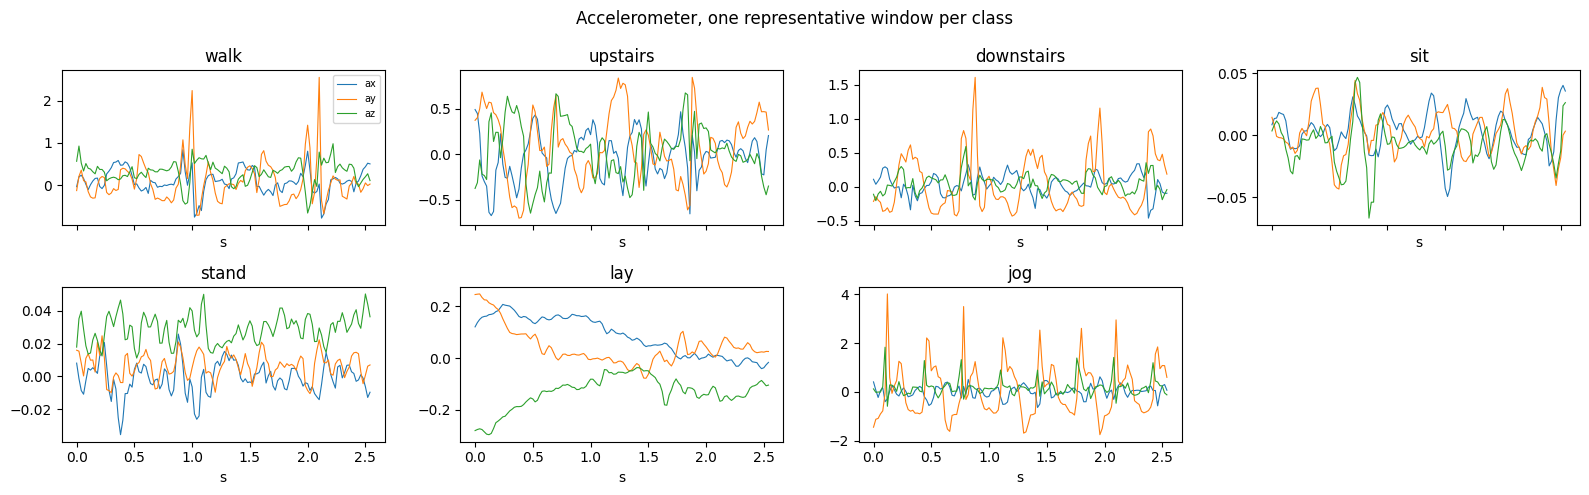

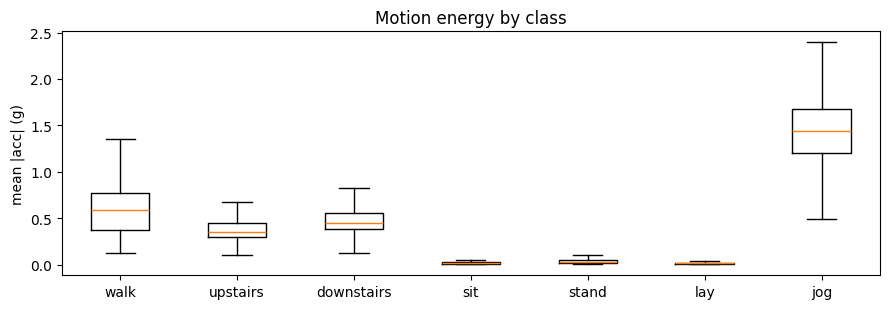

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 5), sharex=True)
for ax, ci in zip(axes.ravel(), range(N_CLS)):
    idx = np.where(y == ci)[0]
    if len(idx) == 0:
        ax.set_title(f"{CLASSES[ci]} (none)"); ax.axis("off"); continue
    w = X[idx[len(idx)//2]]
    t = np.arange(WIN) / FS
    for k, lbl in enumerate(["ax","ay","az"]):
        ax.plot(t, w[:, k], lw=.8, label=lbl)
    ax.set_title(CLASSES[ci]); ax.set_xlabel("s")
axes.ravel()[0].legend(fontsize=7)
axes.ravel()[-1].axis("off")
plt.suptitle("Accelerometer, one representative window per class")
plt.tight_layout(); plt.show()

# Signal energy separates dynamic from static classes -- the feature your
# anomaly scorer will lean on hardest.
energy = np.sqrt((X[:, :, :3]**2).sum(-1)).mean(1)
plt.figure(figsize=(9, 3.2))
labels = [c for i, c in enumerate(CLASSES) if (y == i).any()]
try:
    plt.boxplot([energy[y == i] for i in range(N_CLS) if (y == i).any()],
                tick_labels=labels, showfliers=False)   # matplotlib >= 3.9
except TypeError:
    plt.boxplot([energy[y == i] for i in range(N_CLS) if (y == i).any()],
                labels=labels, showfliers=False)
plt.ylabel("mean |acc| (g)"); plt.title("Motion energy by class")
plt.tight_layout(); plt.show()

## 4. Split by subject
Windows overlap by 50%, so a random window-level split puts *near-duplicate*
windows in both train and test. That inflates accuracy by 5-15 points and the
model falls apart on a new wearer. Split by **person**, always.

In [ ]:
def subject_split(subjects, seed=SEED, fracs=(0.70, 0.15, 0.15)):
    uniq = np.array(sorted(set(subjects)))
    rng = np.random.default_rng(seed); rng.shuffle(uniq)
    n = len(uniq)
    n_tr = max(1, round(fracs[0]*n)); n_va = max(1, round(fracs[1]*n))
    g = {"train": uniq[:n_tr], "val": uniq[n_tr:n_tr+n_va], "test": uniq[n_tr+n_va:]}
    return {k: np.isin(subjects, v) for k, v in g.items()}, g

m, groups = subject_split(subj)
for k in ("train", "val", "test"):
    print(f"{k:5s}: {len(groups[k]):3d} subjects, {m[k].sum():6d} windows")

# assert disjointness -- cheap insurance
assert not (set(groups["train"]) & set(groups["test"])), "subject leak!"
assert not (set(groups["train"]) & set(groups["val"])),  "subject leak!"
assert m["train"].sum() + m["val"].sum() + m["test"].sum() == len(y)
print("\nsplits are subject-disjoint")

train:  38 subjects,  20806 windows
val  :   8 subjects,   5463 windows
test :   8 subjects,   5569 windows

splits are subject-disjoint


In [ ]:
# Normalization statistics from TRAIN ONLY. Using all data here is a subtle
# leak, and these constants must be frozen anyway -- the firmware cannot
# compute mean/std over a dataset it does not have.
train_flat = X[m["train"]].reshape(-1, CH)
MEAN = train_flat.mean(0)
STD  = train_flat.std(0) + 1e-6

Xn = ((X - MEAN) / STD).astype(np.float32)
Xtr, ytr = Xn[m["train"]], y[m["train"]]
Xva, yva = Xn[m["val"]],   y[m["val"]]
Xte, yte = Xn[m["test"]],  y[m["test"]]

print("// paste into firmware:")
print("static const float kMean[6] = {" + ", ".join(f"{v:.6f}f" for v in MEAN) + "};")
print("static const float kStd[6]  = {" + ", ".join(f"{v:.6f}f" for v in STD)  + "};")

np.savez_compressed("movement_data.npz",
                    X_train=Xtr, y_train=ytr, X_val=Xva, y_val=yva,
                    X_test=Xte, y_test=yte, mean=MEAN, std=STD,
                    classes=np.array(CLASSES))
print("\nsaved movement_data.npz")

// paste into firmware:
static const float kMean[6] = {-0.005475f, 0.026250f, 0.027754f, 0.002620f, 0.007673f, 0.009796f};
static const float kStd[6]  = {0.275172f, 0.428611f, 0.296882f, 1.011274f, 0.977802f, 0.637886f};

saved movement_data.npz


## 5. Model

Dilated depthwise-separable convolutions. Dilations 1→2→4→8 give a receptive
field of roughly the full 128-step window while keeping parameter count in the
low tens of thousands.

Every op used here is in TFLM's builtin set and has an ESP-NN int8 kernel:
`CONV_2D`, `DEPTHWISE_CONV_2D`, `MAX_POOL_2D`, `MEAN` (from GAP),
`FULLY_CONNECTED`, `SOFTMAX`. BatchNorm folds into the preceding conv at
conversion time and costs nothing on device.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers as L
tf.random.set_seed(SEED)
print("TF", tf.__version__, "| Keras", tf.keras.__version__, "| numpy", np.__version__)
if int(tf.keras.__version__.split(".")[0]) >= 3:
    print("Keras 3 detected -- the quantization cell handles its TFLite quirk below.")

def ds_block(x, filters, kernel, dilation, name):
    x = L.DepthwiseConv1D(kernel, dilation_rate=dilation, padding="same",
                          use_bias=False, name=f"{name}_dw")(x)
    x = L.BatchNormalization(name=f"{name}_bn1")(x)
    x = L.ReLU(name=f"{name}_r1")(x)
    x = L.Conv1D(filters, 1, use_bias=False, name=f"{name}_pw")(x)
    x = L.BatchNormalization(name=f"{name}_bn2")(x)
    x = L.ReLU(name=f"{name}_r2")(x)
    return x

def build(n_classes=N_CLS, embed_dim=64, width=1.0):
    w = lambda c: max(8, int(c * width))
    inp = L.Input((WIN, CH), name="imu")
    x = L.Conv1D(w(24), 9, strides=2, padding="same", use_bias=False, name="stem")(inp)
    x = L.BatchNormalization()(x); x = L.ReLU()(x)      # 64 x 24
    x = ds_block(x, w(32), 5, 1, "b1"); x = L.MaxPooling1D(2)(x)   # 32 x 32
    x = ds_block(x, w(48), 5, 2, "b2"); x = L.MaxPooling1D(2)(x)   # 16 x 48
    x = ds_block(x, w(64), 3, 4, "b3")
    x = ds_block(x, w(64), 3, 8, "b4")
    x = L.GlobalAveragePooling1D(name="gap")(x)
    emb = L.Dense(embed_dim, activation="relu", name="embedding")(x)
    out = L.Dense(n_classes, activation="softmax", name="probs")(L.Dropout(0.3)(emb))
    return tf.keras.Model(inp, out, name="har"), tf.keras.Model(inp, emb, name="trunk")

model, trunk = build()
model.summary()
print(f"\ntrainable params: {model.count_params():,}  (~{model.count_params()/1024:.0f} KB at int8)")

TF 2.20.0 | Keras 3.13.2 | numpy 2.0.2
Keras 3 detected -- the quantization cell handles its TFLite quirk below.


Model: "har"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imu (InputLayer)                │ (None, 128, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem (Conv1D)                   │ (None, 64, 24)         │         1,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 24)         │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_dw (DepthwiseConv1D)         │ (None, 64, 24)         │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn1 (BatchNormalization)     │ (None, 64, 24)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_r1 (ReLU)                    │ (None, 64, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_pw (Conv1D)                  │ (None, 64, 32)         │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn2 (BatchNormalization)     │ (None, 64, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_r2 (ReLU)                    │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_dw (DepthwiseConv1D)         │ (None, 32, 32)         │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn1 (BatchNormalization)     │ (None, 32, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_r1 (ReLU)                    │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_pw (Conv1D)                  │ (None, 32, 48)         │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn2 (BatchNormalization)     │ (None, 32, 48)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_r2 (ReLU)                    │ (None, 32, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 16, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_dw (DepthwiseConv1D)         │ (None, 16, 48)         │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn1 (BatchNormalization)     │ (None, 16, 48)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_r1 (ReLU)                    │ (None, 16, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_pw (Conv1D)                  │ (None, 16, 64)         │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn2 (BatchNormalization)     │ (None, 16, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_r2 (ReLU)                    │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 17,599 (68.75 KB)

 Trainable params: 16,799 (65.62 KB)

 Non-trainable params: 800 (3.12 KB)


trainable params: 17,599  (~17 KB at int8)


## 6. Train

In [ ]:
# Merging the two datasets leaves 'lay' (UCI-only) and 'jog' (MotionSense-only)
# badly under-represented. Weight the loss rather than resampling, so you keep
# every window.
counts = np.bincount(ytr, minlength=N_CLS).astype(float)
cw = {i: (len(ytr) / (max(1, (counts > 0).sum()) * c)) if c > 0 else 0.0
      for i, c in enumerate(counts)}
print("class weights:", {CLASSES[i]: round(v, 2) for i, v in cw.items()})

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

hist = model.fit(
    Xtr, ytr, validation_data=(Xva, yva),
    epochs=80, batch_size=64, class_weight=cw, verbose=2,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(patience=6, factor=0.5, min_lr=1e-5),
        tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    ])

class weights: {'walk': np.float64(0.66), 'upstairs': np.float64(1.15), 'downstairs': np.float64(1.33), 'sit': np.float64(0.67), 'stand': np.float64(0.69), 'lay': np.float64(1.9), 'jog': np.float64(2.54)}
Epoch 1/80
326/326 - 16s - 48ms/step - accuracy: 0.5842 - loss: 0.8415 - val_accuracy: 0.1289 - val_loss: 2.0523 - learning_rate: 0.0010
Epoch 2/80
326/326 - 9s - 28ms/step - accuracy: 0.7622 - loss: 0.4861 - val_accuracy: 0.7102 - val_loss: 0.8572 - learning_rate: 0.0010
Epoch 3/80
326/326 - 8s - 24ms/step - accuracy: 0.8034 - loss: 0.4096 - val_accuracy: 0.7553 - val_loss: 0.7488 - learning_rate: 0.0010
Epoch 4/80
326/326 - 9s - 28ms/step - accuracy: 0.8398 - loss: 0.3461 - val_accuracy: 0.7964 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 5/80
326/326 - 10s - 29ms/step - accuracy: 0.8526 - loss: 0.3125 - val_accuracy: 0.8148 - val_loss: 0.6422 - learning_rate: 0.0010
Epoch 6/80
326/326 - 8s - 24ms/step - accuracy: 0.8653 - loss: 0.2879 - val_accuracy: 0.7651 - val_loss: 0.7878 -

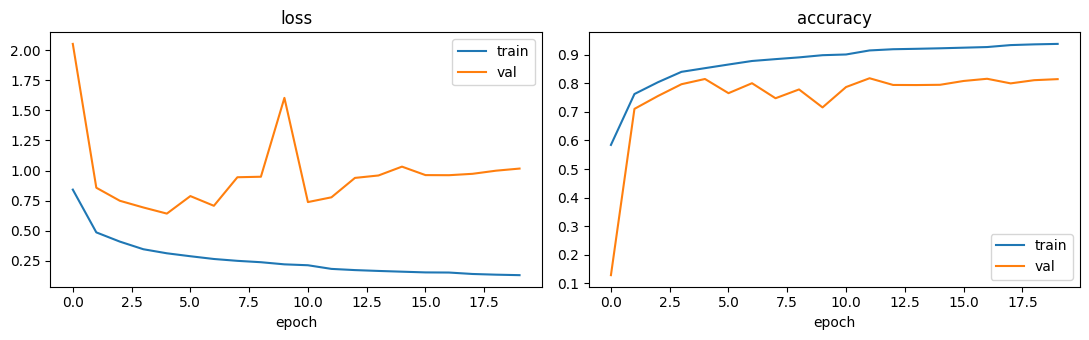

In [ ]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.5))
a1.plot(hist.history["loss"], label="train"); a1.plot(hist.history["val_loss"], label="val")
a1.set_title("loss"); a1.set_xlabel("epoch"); a1.legend()
a2.plot(hist.history["accuracy"], label="train"); a2.plot(hist.history["val_accuracy"], label="val")
a2.set_title("accuracy"); a2.set_xlabel("epoch"); a2.legend()
plt.tight_layout(); plt.show()

## 7. Float evaluation

Calibrate expectations: **high 80s on unseen subjects is a good result** for
6-7 class HAR from body-frame IMU alone. Published 96%+ numbers almost always
come from window-level splits or from the 561 hand-engineered features.

Sit / stand / lay will be your worst classes because gravity was removed from
the input. Confusion *within* the static group is fine. Confusion *between*
static and dynamic is not — that's what your threat logic depends on.

float32 held-out accuracy: 0.8111

              precision    recall  f1-score   support

        walk       0.92      0.78      0.84      1265
    upstairs       0.65      0.91      0.76       667
  downstairs       0.76      0.74      0.75       593
         sit       0.74      0.99      0.85      1273
       stand       0.99      0.69      0.81      1163
         lay       0.48      0.25      0.33       187
         jog       1.00      0.90      0.95       421

    accuracy                           0.81      5569
   macro avg       0.79      0.75      0.75      5569
weighted avg       0.84      0.81      0.81      5569



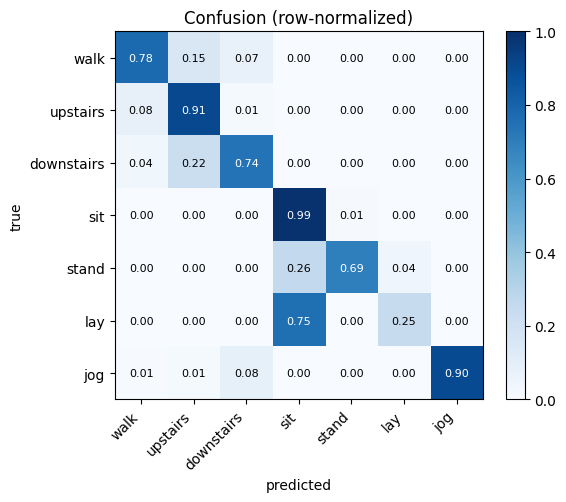

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

loss, acc = model.evaluate(Xte, yte, verbose=0)
print(f"float32 held-out accuracy: {acc:.4f}\n")

pred_f = model.predict(Xte, verbose=0).argmax(1)
present = [i for i in range(N_CLS) if (yte == i).any() or (pred_f == i).any()]
print(classification_report(yte, pred_f, labels=present,
                            target_names=[CLASSES[i] for i in present],
                            zero_division=0))

cm = confusion_matrix(yte, pred_f, labels=present, normalize="true")
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(len(present)), [CLASSES[i] for i in present], rotation=45, ha="right")
plt.yticks(range(len(present)), [CLASSES[i] for i in present])
for r in range(len(present)):
    for c in range(len(present)):
        plt.text(c, r, f"{cm[r,c]:.2f}", ha="center", va="center",
                 fontsize=8, color="white" if cm[r,c] > .5 else "black")
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("Confusion (row-normalized)")
plt.colorbar(); plt.tight_layout(); plt.show()

## 8. Quantize to int8

Full-integer quantization: weights *and* activations, int8 in and int8 out, so
no float kernels are pulled into the firmware. The representative dataset
determines the activation ranges — draw it from training data only, and use a
few hundred diverse windows rather than one class.

In [ ]:
def to_int8(keras_model, rep_x, path, n_rep=300):
    sel = np.random.default_rng(SEED).choice(len(rep_x), min(n_rep, len(rep_x)),
                                             replace=False)

    def configure(conv):
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
        conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        conv.inference_input_type  = tf.int8
        conv.inference_output_type = tf.int8
        conv.representative_dataset = lambda: (
            [rep_x[i:i+1].astype(np.float32)] for i in sel)
        return conv.convert()

    try:
        blob = configure(tf.lite.TFLiteConverter.from_keras_model(keras_model))
    except Exception as e:
        # Keras 3 (TF >= 2.16) frequently refuses from_keras_model. Exporting a
        # SavedModel first is the supported route and produces an identical graph.
        print(f"  from_keras_model failed ({type(e).__name__}), using SavedModel route")
        sm = f"/tmp/sm_{keras_model.name}"
        shutil.rmtree(sm, ignore_errors=True)
        keras_model.export(sm)
        blob = configure(tf.lite.TFLiteConverter.from_saved_model(sm))

    open(path, "wb").write(blob)
    print(f"{path:26s} {len(blob)/1024:7.1f} KB")
    return blob

blob_cls = to_int8(model, Xtr, "movement_int8.tflite")
blob_emb = to_int8(trunk, Xtr, "embedding_int8.tflite")

Saved artifact at '/tmp/tmpef91rjoi'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='imu')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  137195133376208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133376784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133379472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133379088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133377936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133379664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133378128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133380048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137198130446160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133378896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133377744: TensorSpec(

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


movement_int8.tflite          46.8 KB
Saved artifact at '/tmp/tmp464ktfuv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='imu')
Output Type:
  TensorSpec(shape=(None, 64), dtype=tf.float32, name=None)
Captures:
  137195133376208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133376784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133379472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133379088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133377936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133379664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133378128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133380048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137198130446160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137195133378896: TensorSpec(shape=(), dtype=tf.resource, na

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


embedding_int8.tflite         44.6 KB


In [ ]:
# Always re-measure after quantizing. int8 typically costs 0-2 points; if it
# costs more than ~4, your representative dataset was not diverse enough.
def tflite_predict(blob, Xf):
    itp = tf.lite.Interpreter(model_content=blob); itp.allocate_tensors()
    ind, outd = itp.get_input_details()[0], itp.get_output_details()[0]
    si, zi = ind["quantization"]; so, zo = outd["quantization"]
    outs = []
    for x in Xf:
        q = np.clip(np.round(x/si + zi), -128, 127).astype(np.int8)
        itp.set_tensor(ind["index"], q[None]); itp.invoke()
        outs.append((itp.get_tensor(outd["index"])[0].astype(np.float32) - zo) * so)
    return np.array(outs)

probs_q = tflite_predict(blob_cls, Xte)
pred_q  = probs_q.argmax(1)
print(f"float32: {acc:.4f}")
print(f"int8   : {(pred_q==yte).mean():.4f}   (delta {(pred_q==yte).mean()-acc:+.4f})")
print(f"agreement with float model: {(pred_q==pred_f).mean():.4f}\n")
for i in present:
    msk = yte == i
    if msk.any():
        print(f"  {CLASSES[i]:11s} recall {(pred_q[msk]==i).mean():.3f}  (n={msk.sum()})")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


float32: 0.8111
int8   : 0.7834   (delta -0.0277)
agreement with float model: 0.8664

  walk        recall 0.794  (n=1265)
  upstairs    recall 0.900  (n=667)
  downstairs  recall 0.747  (n=593)
  sit         recall 0.775  (n=1273)
  stand       recall 0.807  (n=1163)
  lay         recall 0.091  (n=187)
  jog         recall 0.891  (n=421)


## 9. Normality scorer — the part that votes on threat

With no distress labels, the honest formulation is one-class: learn what normal
motion looks like, score deviation. Two cheap signals, both computable on device
from outputs you already have:

- **Predictive entropy** — a window unlike any training activity produces a flat
  softmax. High entropy ⇒ unfamiliar motion.
- **Embedding distance** — Mahalanobis distance from the training embedding
  distribution. Sharper than entropy, costs one 64×64 matrix (16 KB float, or
  precompute the Cholesky factor).

The threshold below is calibrated as a percentile of *normal* data, i.e. an
explicit false-positive budget. Set it by how many false alarms per hour you can
tolerate, not by guessing.

entropy threshold     0.5330
mahalanobis threshold 15.1715
flagged on held-out normal data: entropy 1.6%, mahalanobis 2.0%
(both are false positives -- every test window is normal activity)


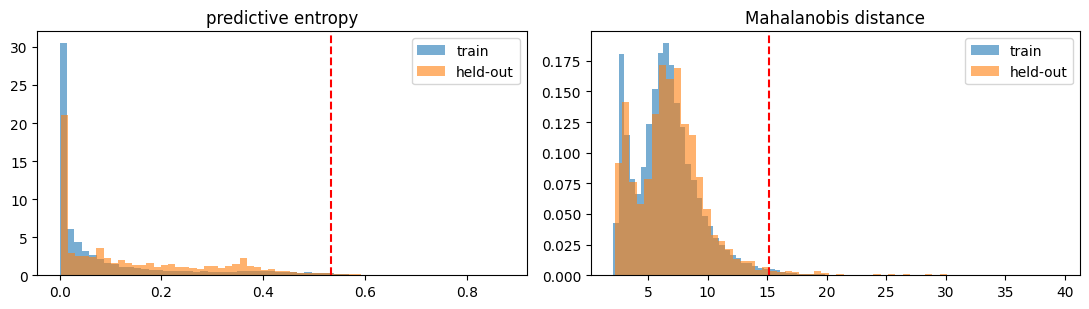

In [ ]:
def entropy(p, eps=1e-9):
    p = np.clip(p, eps, 1.0)
    return -(p * np.log(p)).sum(-1) / np.log(p.shape[-1])   # normalized 0..1

emb_tr = trunk.predict(Xtr, verbose=0)
mu = emb_tr.mean(0)
cov = np.cov(emb_tr.T) + np.eye(emb_tr.shape[1]) * 1e-3
P = np.linalg.inv(cov)

def mahalanobis(E):
    d = E - mu
    return np.sqrt(np.einsum("ij,jk,ik->i", d, P, d))

ent_tr, ent_te = entropy(model.predict(Xtr, verbose=0)), entropy(probs_q)
mah_tr, mah_te = mahalanobis(emb_tr), mahalanobis(trunk.predict(Xte, verbose=0))

# 1% false-positive budget on normal training motion
THR_ENT = float(np.percentile(ent_tr, 99))
THR_MAH = float(np.percentile(mah_tr, 99))
print(f"entropy threshold     {THR_ENT:.4f}")
print(f"mahalanobis threshold {THR_MAH:.4f}")
print(f"flagged on held-out normal data: "
      f"entropy {100*(ent_te>THR_ENT).mean():.1f}%, "
      f"mahalanobis {100*(mah_te>THR_MAH).mean():.1f}%")
print("(both are false positives -- every test window is normal activity)")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2))
a1.hist(ent_tr, bins=60, alpha=.6, density=True, label="train")
a1.hist(ent_te, bins=60, alpha=.6, density=True, label="held-out")
a1.axvline(THR_ENT, color="r", ls="--"); a1.set_title("predictive entropy"); a1.legend()
a2.hist(mah_tr, bins=60, alpha=.6, density=True, label="train")
a2.hist(mah_te, bins=60, alpha=.6, density=True, label="held-out")
a2.axvline(THR_MAH, color="r", ls="--"); a2.set_title("Mahalanobis distance"); a2.legend()
plt.tight_layout(); plt.show()

In [ ]:
# Synthetic stress test. This is NOT validation -- it only confirms the scorer
# reacts to out-of-distribution motion at all. Do not report these numbers as
# threat-detection performance; you have not tested on a single real event.
rng = np.random.default_rng(SEED)
base = Xte[rng.choice(len(Xte), 400)]

shake  = base + rng.normal(0, 3.0, base.shape).astype(np.float32)      # violent shaking
impact = base.copy()
for w in impact:                                                       # sudden impact spike
    t = rng.integers(20, WIN-20); w[t:t+8] += rng.normal(0, 8, (8, CH))
freeze = np.repeat(base[:, :1, :], WIN, axis=1) + rng.normal(0, .02, base.shape).astype(np.float32)

for name, Xa in [("normal (held-out)", Xte), ("shaking", shake),
                 ("impact spike", impact), ("abnormal stillness", freeze)]:
    e = entropy(model.predict(Xa, verbose=0)); mh = mahalanobis(trunk.predict(Xa, verbose=0))
    print(f"{name:20s} entropy>thr {100*(e>THR_ENT).mean():5.1f}%   "
          f"mahal>thr {100*(mh>THR_MAH).mean():5.1f}%")

normal (held-out)    entropy>thr   2.1%   mahal>thr   2.0%
shaking              entropy>thr   4.8%   mahal>thr  34.2%
impact spike         entropy>thr  13.5%   mahal>thr  46.0%
abnormal stillness   entropy>thr   4.5%   mahal>thr  37.2%


## 10. Export for ESP-IDF

In [ ]:
def emit_c(blob, stem, symbol):
    with open(f"{stem}.h", "w") as f:
        f.write(textwrap.dedent(f'''
            #pragma once
            extern const unsigned char {symbol}[];
            extern const unsigned int {symbol}_len;
            ''').lstrip())
    with open(f"{stem}.cc", "w") as f:
        f.write(f'#include "{stem}.h"\n\n')
        f.write(f"const unsigned int {symbol}_len = {len(blob)};\n")
        f.write(f"alignas(16) const unsigned char {symbol}[] = {{\n")
        for i in range(0, len(blob), 12):
            f.write("  " + ", ".join(f"0x{b:02x}" for b in blob[i:i+12]) + ",\n")
        f.write("};\n")
    print(f"wrote {stem}.h / {stem}.cc  ({len(blob)/1024:.1f} KB in .rodata)")

emit_c(blob_cls, "movement_model_data", "g_movement_model_data")

cfg = {"win": WIN, "channels": CH, "fs": FS, "classes": CLASSES,
       "mean": MEAN.tolist(), "std": STD.tolist(),
       "thr_entropy": THR_ENT, "thr_mahalanobis": THR_MAH}
json.dump(cfg, open("movement_config.json", "w"), indent=2)
print("wrote movement_config.json")

wrote movement_model_data.h / movement_model_data.cc  (46.8 KB in .rodata)
wrote movement_config.json


In [ ]:
# Rough arena estimate. TFLM's real figure differs (alignment, scratch buffers,
# op-specific temporaries) -- treat this as a lower bound and confirm on device
# with interpreter.arena_used_bytes() after the first Invoke().
itp = tf.lite.Interpreter(model_content=blob_cls)
itp.allocate_tensors()
biggest = 0
for d in itp.get_tensor_details():
    if d["shape"].size:
        nbytes = int(np.prod(d["shape"])) * np.dtype(d["dtype"]).itemsize
        biggest = max(biggest, nbytes)
print(f"largest single tensor : {biggest/1024:.1f} KB")
print(f"model in flash        : {len(blob_cls)/1024:.1f} KB")
print(f"suggested arena start : 100 KB, then shrink to arena_used_bytes() * 1.1")
print("\nops in this model (register exactly these, not AllOpsResolver):")
print(" ", sorted({d['op_name'] for d in itp._get_ops_details()}))

largest single tensor : 4.0 KB
model in flash        : 46.8 KB
suggested arena start : 100 KB, then shrink to arena_used_bytes() * 1.1

ops in this model (register exactly these, not AllOpsResolver):
  ['ADD', 'BATCH_TO_SPACE_ND', 'CONV_2D', 'DELEGATE', 'DEPTHWISE_CONV_2D', 'EXPAND_DIMS', 'FULLY_CONNECTED', 'MAX_POOL_2D', 'MEAN', 'MUL', 'RESHAPE', 'SOFTMAX', 'SPACE_TO_BATCH_ND']


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


### Firmware sketch

```cpp
#include "tensorflow/lite/micro/micro_interpreter.h"
#include "tensorflow/lite/micro/micro_mutable_op_resolver.h"
#include "movement_model_data.h"

constexpr int kArenaSize = 100 * 1024;
static uint8_t tensor_arena[kArenaSize];   // static, never malloc'd

// Registering only what you use saves 30-50 KB of flash vs AllOpsResolver.
static tflite::MicroMutableOpResolver<8> resolver;
resolver.AddConv2D();
resolver.AddDepthwiseConv2D();
resolver.AddMaxPool2D();
resolver.AddMean();            // from GlobalAveragePooling1D
resolver.AddFullyConnected();
resolver.AddSoftmax();
resolver.AddQuantize();
resolver.AddDequantize();

const tflite::Model* m = tflite::GetModel(g_movement_model_data);
tflite::MicroInterpreter interp(m, resolver, tensor_arena, kArenaSize);
interp.AllocateTensors();
ESP_LOGI(TAG, "arena used: %d bytes", interp.arena_used_bytes());  // <-- shrink to this

// Per window: ring-buffer 128 samples, then for each channel c and step t
//   q = (int8_t) roundf((raw[t][c] - kMean[c]) / kStd[c] / in_scale + in_zero_point);
```

Add `esp-tflite-micro` as an IDF component:
```bash
idf.py add-dependency "espressif/esp-tflite-micro"
```
On the **ESP32-S3**, enable ESP-NN (`CONFIG_NN_OPTIMIZATIONS=y`) for 3-8× faster
int8 convolutions. Plain ESP32 has no vector unit and will be considerably slower —
measure inference latency against your window stride (2.56 s window, 1.28 s hop
means you have 1.28 s of budget per inference; you will have far more headroom
than that).

## 11. What to do next

**Before you trust any of this, collect real data.** Everything above is
scaffolding around a hole where distress labels should be. The scorer reacts to
"unlike normal motion," and shaking a phone in your hand is unlike normal
motion — but so is riding a motorbike over a broken road in Dhaka, and so is
dancing. You cannot tell those apart from HAR data. Concretely:

1. **Wear the device and log normal life** for a week or two — commute, work,
   stairs, rickshaw, bus, cooking, exercise. Every false positive you find here
   is one you would otherwise have shipped. This matters more than any model
   change.
2. **Collect a few hundred staged distress windows** — phone grabbed, arm
   wrenched, running while flailing, sudden drop, struggle on the ground. Then
   fine-tune: freeze the trunk, retrain only the head on a *binary* task. A
   couple of hundred windows is enough for that with a frozen backbone.
3. **Add a fall dataset** (SisFall, MobiAct, UMAFall) as a public proxy for
   sudden violent events, since falls are the closest labelled analogue.
4. **Then fuse.** Feed this branch's embedding plus its anomaly score into the
   2-of-3 vote alongside the acoustic and HR branches. Keep the branches
   separate on device — three small models with three small arenas is far easier
   to fit in 520 KB than one fused model, and you can update them independently.

One design note worth weighing early: a personal-safety device's cost of a false
negative and cost of a false positive are wildly asymmetric, and both are real.
Too many false alarms and the wearer switches it off, which makes your recall
zero in practice. Whatever threshold you pick, keep the entropy and Mahalanobis
scores in the telemetry so you can re-tune from field data instead of guessing again.